<a href="https://colab.research.google.com/github/Erkgrcsll/pharmacy-demand-forecasting/blob/main/Pharmacy_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORT LIBRARY
# =============================================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

import shap

In [ ]:
# LOAD DATASET
# =============================================================================

uploaded = files.upload()

df = pd.read_csv("global_test_set.csv")
df.head()

Saving global_test_set.csv to global_test_set.csv


,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
0,1195586,1062,A.M-E.C,gerawa,1,1,1,4/7/2024,2:52PM,Drug
1,1195586,1063,R.A-C,gerawa,1,1,1,4/7/2024,2:52PM,Drug
2,1195586,8.90425E+12,istovin 20mg,Capsule,3,2,0,4/7/2024,2:51PM,Drug
3,1195586,4.26022E+12,caelin %2 sulfur,Soap,1,1,1,4/7/2024,2:51PM,Supply
4,1195586,4.26012E+12,TMS forte 800/160mg,Tablet,1,2,2,4/7/2024,2:51PM,Drug


In [ ]:
# DATASET OVERVIEW
# =============================================================================

df.info()

df.describe()

df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240591 entries, 0 to 240590
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Invoice      240591 non-null  int64 
 1   barcode      240591 non-null  object
 2   name         240591 non-null  object
 3   dosage_form  222288 non-null  object
 4   Sheet        240591 non-null  int64 
 5   Sales_Sheet  240591 non-null  int64 
 6   Sales_pack   240591 non-null  int64 
 7   addeddate    240591 non-null  object
 8   time_        240591 non-null  object
 9   type         240591 non-null  object
dtypes: int64(4), object(6)
memory usage: 18.4+ MB


,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
30388,1316915,8.40274E+11,queen aromatherapy grad,Soap,1,1,1,9/9/2024,4:28PM,Supply
99975,264763,8.43701E+12,Meditopic SaliTopic,Gel,1,1,1,12/3/2024,4:56PM,Supply
45877,1383726,5.00028E+12,Tamsulosin 0.4mg - zentiva,Tablet,2,2,1,1/25/2024,5:08PM,Drug
17787,1261288,5.06001E+12,Indometacin 25mg,Capsule,2,2,1,4/21/2024,2:57PM,Drug
124700,419114,3.76025E+12,Sitadin M 1000mg/50mg,Tablet,8,2,0,9/16/2024,2:42PM,Drug


In [ ]:
# DATA QUALITY ASSESSMENT
# =============================================================================

# 4.1 MISSING VALUES ANALYSIS
# =============================================================================

df.isnull().sum()

,0
Invoice,0
barcode,0
name,0
dosage_form,18303
Sheet,0
Sales_Sheet,0
Sales_pack,0
addeddate,0
time_,0
type,0


In [ ]:
# 4.2 DUPLICATE RECORDS ANALYSIS
# =============================================================================

df.duplicated().sum()

np.int64(1637)

In [ ]:
# 4.3 DATA TYPE VALIDATION
# =============================================================================

df.dtypes

,0
Invoice,int64
barcode,object
name,object
dosage_form,object
Sheet,int64
Sales_Sheet,int64
Sales_pack,int64
addeddate,object
time_,object
type,object


In [ ]:
# DATA CLEANING PIPELINE
# =============================================================================

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df["dosage_form"] = df["dosage_form"].fillna("Unknown")

# Convert date
df["addeddate"] = pd.to_datetime(df["addeddate"])

# Check results
print(df.isnull().sum())
print(df.duplicated().sum())

/tmp/ipykernel_2726/3251358436.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["dosage_form"] = df["dosage_form"].fillna("Unknown")
/tmp/ipykernel_2726/3251358436.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["addeddate"] = pd.to_datetime(df["addeddate"])


Invoice        0
barcode        0
name           0
dosage_form    0
Sheet          0
Sales_Sheet    0
Sales_pack     0
addeddate      0
time_          0
type           0
dtype: int64
0


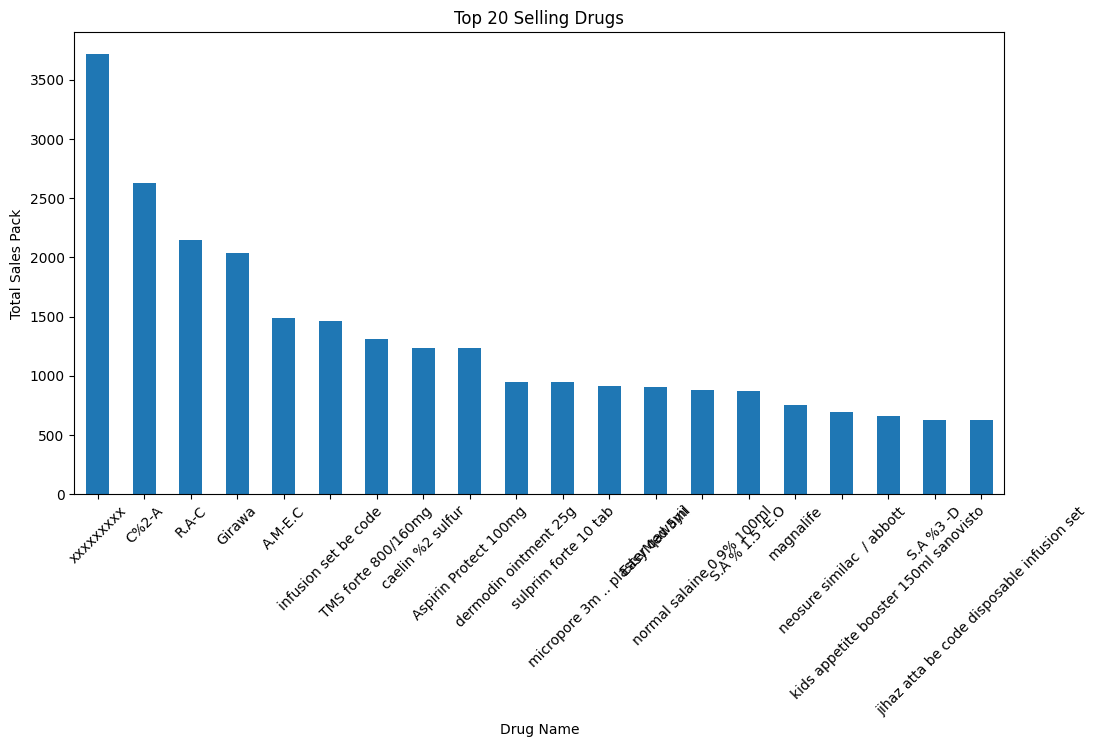

In [ ]:
# EDA 5. TOP SELLING DRUGS ANALYSIS
# =============================================================================

top_drugs = (
    df.groupby("name")["Sales_pack"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(12,6))
top_drugs.plot(kind="bar")

plt.title("Top 20 Selling Drugs")
plt.xlabel("Drug Name")
plt.ylabel("Total Sales Pack")
plt.xticks(rotation=45)
plt.show()

In [ ]:
product_df = product_df[
    product_df['drug_name'].notna()
]

product_df = product_df[
    product_df['drug_name'].str.len() > 2
]

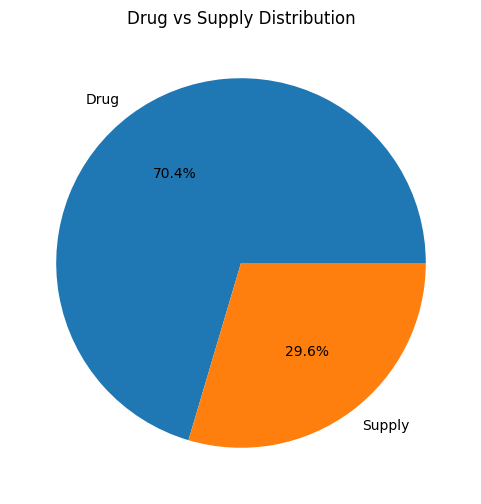

In [ ]:
# DRUG TYPE DISTRIBUTION
# =============================================================================

plt.figure(figsize=(6,6))

df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Drug vs Supply Distribution")
plt.ylabel("")
plt.show()

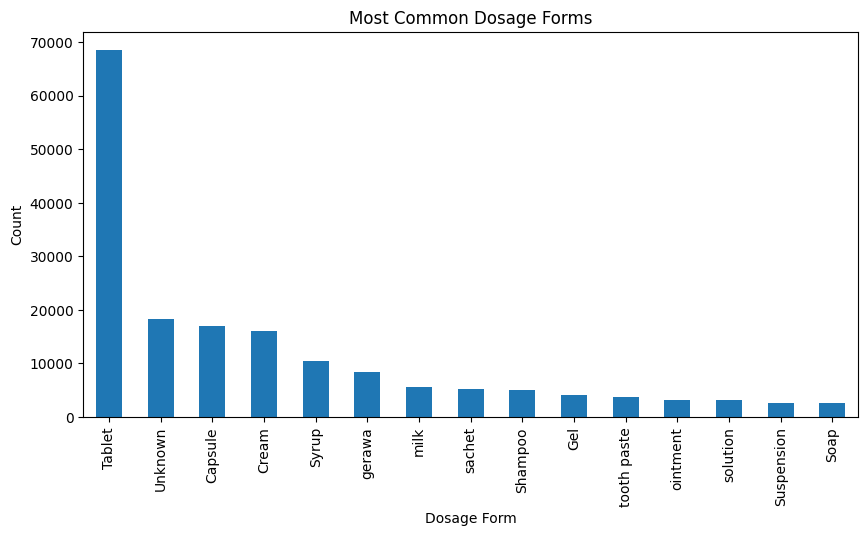

In [ ]:
# DOSAGE FORM ANALYSIS
# =============================================================================

top_dosage = (
    df["dosage_form"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,5))
top_dosage.plot(kind="bar")

plt.title("Most Common Dosage Forms")
plt.xlabel("Dosage Form")
plt.ylabel("Count")
plt.show()

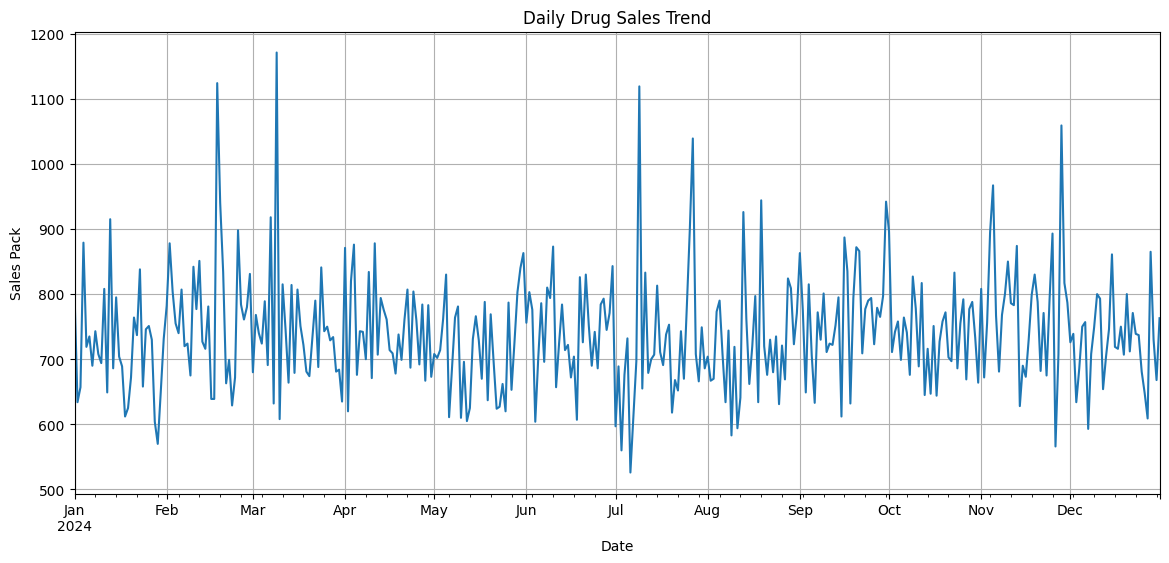

In [ ]:
# DAILY SALES TREND
# =============================================================================

daily_sales = (
    df.groupby("addeddate")["Sales_pack"]
      .sum()
)

plt.figure(figsize=(14,6))

daily_sales.plot()

plt.title("Daily Drug Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales Pack")
plt.grid(True)

plt.show()

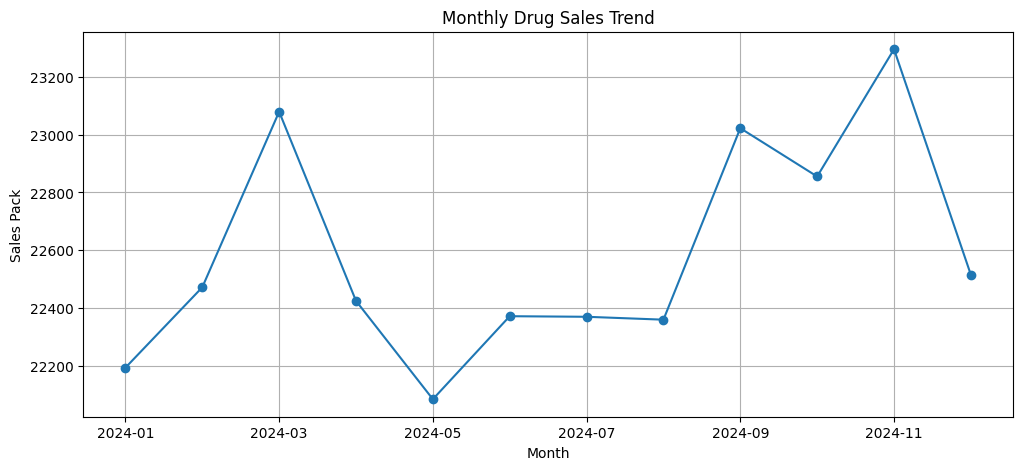

In [ ]:
# MONTHLY SALES TREND
# =============================================================================

monthly_sales = (
    df.groupby(
        df["addeddate"].dt.to_period("M")
    )["Sales_pack"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Drug Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Pack")

plt.grid(True)
plt.show()

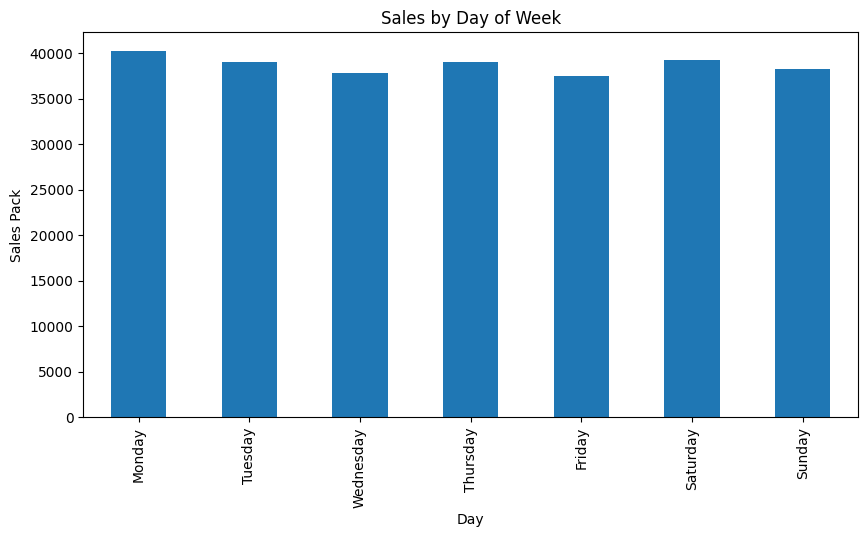

In [ ]:
# DAYS OF WEEK ANALYSIS
# =============================================================================

df["day_name"] = df["addeddate"].dt.day_name()

weekday_sales = (
    df.groupby("day_name")["Sales_pack"]
      .sum()
)

order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(order)

plt.figure(figsize=(10,5))

weekday_sales.plot(kind="bar")

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Sales Pack")

plt.show()

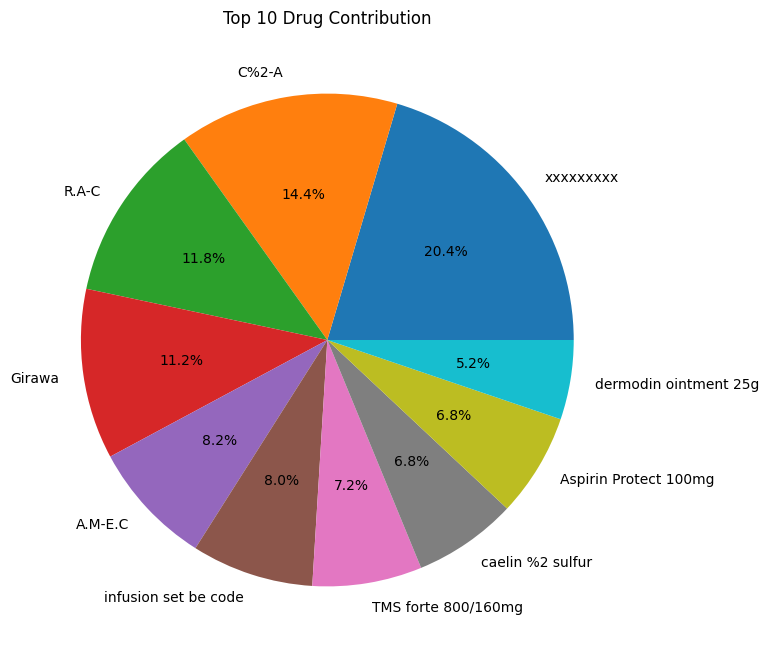

In [ ]:
# TOP 10 DRUGS CONTRIBUTION
# =============================================================================

drug_sales = (
    df.groupby("name")["Sales_pack"]
      .sum()
      .sort_values(ascending=False)
)

top10 = drug_sales.head(10)

plt.figure(figsize=(8,8))

top10.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Top 10 Drug Contribution")
plt.ylabel("")

plt.show()

/tmp/ipykernel_2726/3636968248.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time_"] = pd.to_datetime(
/tmp/ipykernel_2726/3636968248.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time_"] = pd.to_datetime(
/tmp/ipykernel_2726/3636968248.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hour"] = df["time_"].dt.hour


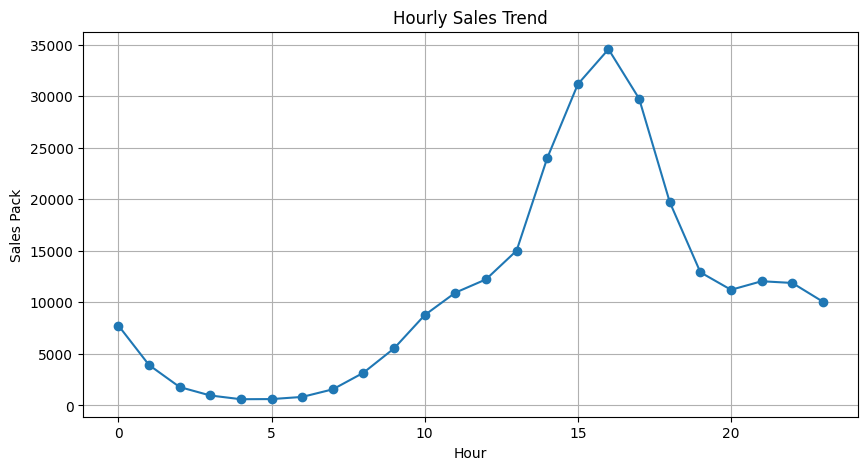

In [ ]:
# HOURLY SALES ANALYSIS
# =============================================================================

df["time_"] = pd.to_datetime(
    df["time_"],
    errors="coerce"
)

df["hour"] = df["time_"].dt.hour

hourly_sales = (
    df.groupby("hour")["Sales_pack"]
      .sum()
)

plt.figure(figsize=(10,5))

hourly_sales.plot(marker="o")

plt.title("Hourly Sales Trend")
plt.xlabel("Hour")
plt.ylabel("Sales Pack")

plt.grid(True)

plt.show()

In [ ]:
# PREPARE DATA FOR PROPHET FORECASTING
# =============================================================================

forecast_df = (
    df.groupby("addeddate")["Sales_pack"]
      .sum()
      .reset_index()
)

forecast_df.columns = ["ds", "y"]

forecast_df.head()

,ds,y
0,2024-01-01,802
1,2024-01-02,634
2,2024-01-03,657
3,2024-01-04,879
4,2024-01-05,719


In [ ]:
# TRAIN PROPHET MODEL
# =============================================================================

from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(forecast_df)

In [ ]:
# FORECAST NEXT 90 DAYS
# =============================================================================

future = model.make_future_dataframe(
    periods=90
)

forecast = model.predict(future)

forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
451,2025-03-27,701.163257,596.885163,811.483105
452,2025-03-28,672.406650,563.591124,777.444106
453,2025-03-29,705.604903,604.256387,815.577672
454,2025-03-30,688.595255,584.509919,795.946877
455,2025-03-31,712.164706,607.276187,818.921678


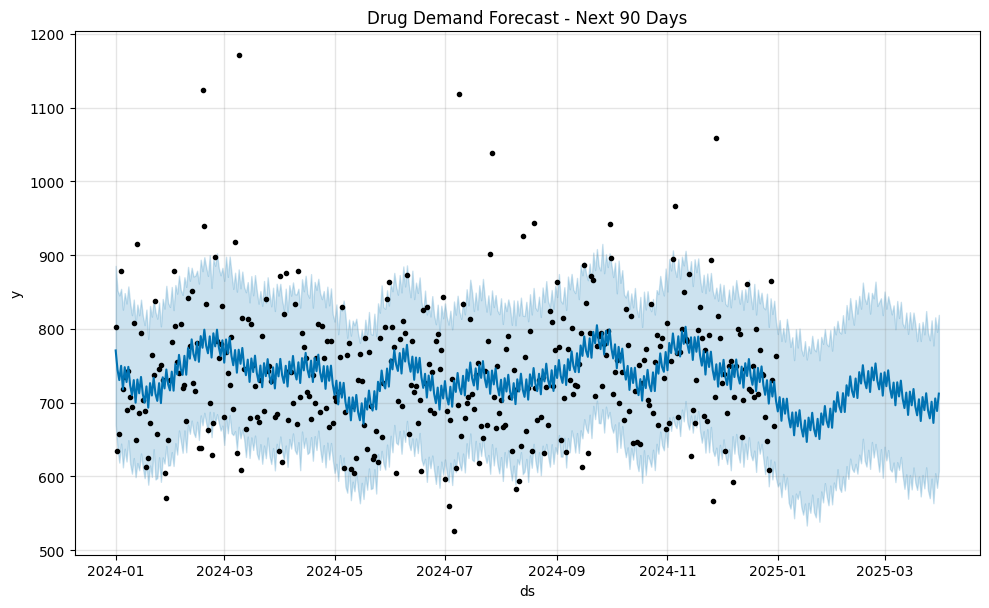

In [ ]:
# SALES FORECAST
# =============================================================================

fig = model.plot(forecast)

plt.title("Drug Demand Forecast - Next 90 Days")

plt.show()

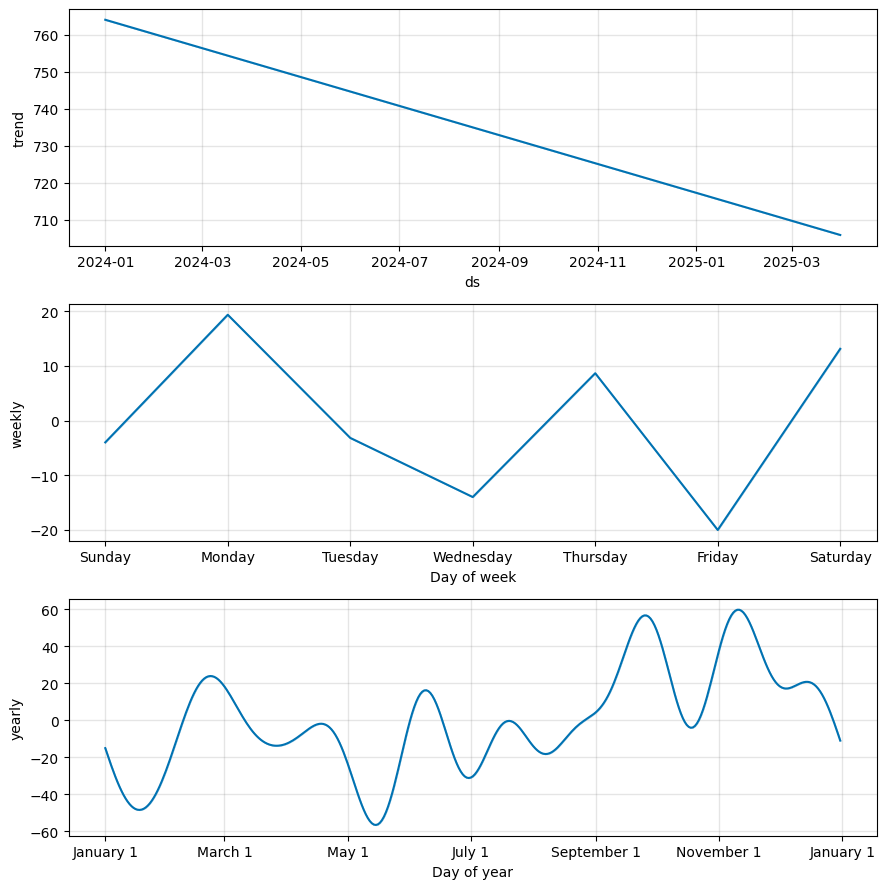

In [ ]:
# SEASONALITY COMPONENTS
# =============================================================================

model.plot_components(forecast)

plt.show()

In [ ]:
# TOP PRODUCTS BY SALES VOLUME
# =============================================================================

inventory_df = (
    df.groupby("name")["Sales_pack"]
      .sum()
      .reset_index()
)

inventory_df = inventory_df.sort_values(
    by="Sales_pack",
    ascending=False
)

inventory_df.head()

,name,Sales_pack
21754,xxxxxxxxx,3715
2427,C%2-A,2628
12139,R.A-C,2148
6332,Girawa,2034
72,A.M-E.C,1486


In [ ]:
# ABC INVENTORY ANALYSIS
# =============================================================================

abc_df = df.groupby("name")["Sales_pack"].sum().reset_index()

abc_df.columns = [
    "Drug",
    "Total_Sales"
]

abc_df = abc_df.sort_values(
    by="Total_Sales",
    ascending=False
)

abc_df["Sales_Percentage"] = (
    abc_df["Total_Sales"]
    / abc_df["Total_Sales"].sum()
) * 100

abc_df["Cumulative_Percentage"] = (
    abc_df["Sales_Percentage"].cumsum()
)

def abc_class(x):

    if x <= 80:
        return "A"

    elif x <= 95:
        return "B"

    else:
        return "C"

abc_df["ABC_Class"] = (
    abc_df["Cumulative_Percentage"]
    .apply(abc_class)
)

abc_df.head()

,Drug,Total_Sales,Sales_Percentage,Cumulative_Percentage,ABC_Class
21754,xxxxxxxxx,3715,1.370626,1.370626,A
2427,C%2-A,2628,0.969584,2.340210,A
12139,R.A-C,2148,0.792491,3.132702,A
6332,Girawa,2034,0.750432,3.883133,A
72,A.M-E.C,1486,0.548250,4.431384,A


ABC_Class
C    10473
B     6953
A     4444
Name: count, dtype: int64


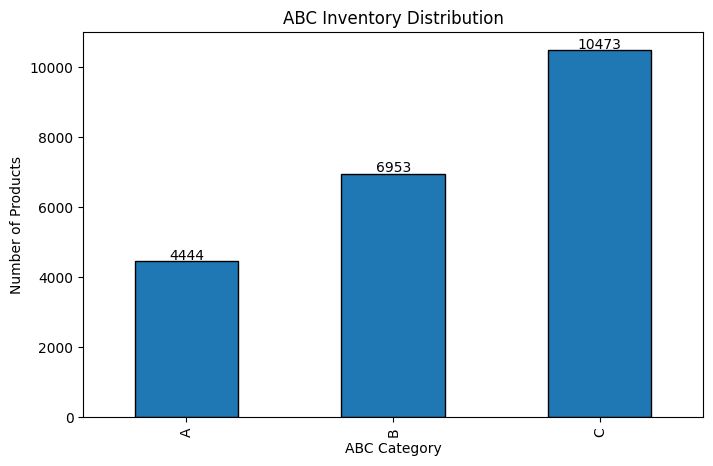

In [ ]:
# ABC INVENTORY DISTRIBUTION
# ============================================================

abc_distribution = abc_df["ABC_Class"].value_counts()

print(abc_distribution)

plt.figure(figsize=(8,5))

abc_distribution.sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("ABC Inventory Distribution")
plt.xlabel("ABC Category")
plt.ylabel("Number of Products")

for i, v in enumerate(abc_distribution.sort_index()):
    plt.text(i, v+50, str(v), ha='center')

plt.show()

In [ ]:
# CREATE STOCKOUT RISK DATASET
# =============================================================================

risk_df = (
    df.groupby("name")
      .agg({
          "Sales_pack":"sum",
          "Invoice":"count"
      })
      .reset_index()
)

risk_df.columns = [
    "name",
    "total_sales",
    "transaction_count"
]

risk_df.head()

,name,total_sales,transaction_count
0,Fruit mask,8,7
1,Govils clove oil 10ml / eurostar,7,7
2,Hollywood flawless filter,1,1
3,Kamill express balsam hand & nagelcrewmw,1,1
4,LISTERINE SPEARMINT,2,2


In [ ]:
# STOCKOUT PROXY LABEL
# =============================================================================

threshold = risk_df["total_sales"].quantile(0.80)

risk_df["stockout_risk"] = (
    risk_df["total_sales"] >= threshold
).astype(int)

risk_df.head()

,name,total_sales,transaction_count,stockout_risk
0,Fruit mask,8,7,0
1,Govils clove oil 10ml / eurostar,7,7,0
2,Hollywood flawless filter,1,1,0
3,Kamill express balsam hand & nagelcrewmw,1,1,0
4,LISTERINE SPEARMINT,2,2,0


In [ ]:
# XGBOOST DEMAND RISK MODEL
# =============================================================================

from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

model_xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# MODEL EVALUATION
# =============================================================================

from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

pred_prob = model_xgb.predict_proba(X_test)[:,1]

pred_class = model_xgb.predict(X_test)

auc = roc_auc_score(
    y_test,
    pred_prob
)

print("ROC-AUC:", round(auc,4))

print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        pred_class
    )
)

ROC-AUC: 0.9916

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3482
           1       0.92      0.93      0.92       892

    accuracy                           0.97      4374
   macro avg       0.95      0.95      0.95      4374
weighted avg       0.97      0.97      0.97      4374



In [ ]:
# MODEL EVALUATION
# =============================================================================

from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

pred_prob = model_xgb.predict_proba(X_test)[:,1]

pred_class = model_xgb.predict(X_test)

auc = roc_auc_score(
    y_test,
    pred_prob
)

print("ROC-AUC:", round(auc,4))

print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        pred_class
    )
)

ROC-AUC: 0.9916

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3482
           1       0.92      0.93      0.92       892

    accuracy                           0.97      4374
   macro avg       0.95      0.95      0.95      4374
weighted avg       0.97      0.97      0.97      4374



In [ ]:
# FEATURE ENGINEERING
# =============================================================================

df["addeddate"] = pd.to_datetime(df["addeddate"])

risk_df = (
    df.groupby("name")
    .agg(
        transaction_count=("Invoice","count"),
        total_sales=("Sales_pack","sum"),
        avg_sales=("Sales_pack","mean"),
        sales_std=("Sales_pack","std"),
        unique_days=("addeddate","nunique")
    )
    .reset_index()
)

risk_df.fillna(0, inplace=True)

risk_df.head()

/tmp/ipykernel_2726/2972238400.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["addeddate"] = pd.to_datetime(df["addeddate"])


,name,transaction_count,total_sales,avg_sales,sales_std,unique_days
0,Fruit mask,7,8,1.142857,0.377964,6
1,Govils clove oil 10ml / eurostar,7,7,1.000000,0.000000,7
2,Hollywood flawless filter,1,1,1.000000,0.000000,1
3,Kamill express balsam hand & nagelcrewmw,1,1,1.000000,0.000000,1
4,LISTERINE SPEARMINT,2,2,1.000000,0.000000,2


In [ ]:
# HIGH DEMAND DRUG LABEL
# =============================================================================

threshold = risk_df["total_sales"].quantile(0.80)

risk_df["high_demand"] = (
    risk_df["total_sales"] >= threshold
).astype(int)

risk_df["high_demand"].value_counts()

,count
high_demand,
0,17418
1,4452


In [ ]:
# FEATURE SELECTION
# =============================================================================

X = risk_df[
    [
        "transaction_count",
        "avg_sales",
        "sales_std",
        "unique_days"
    ]
]

y = risk_df["high_demand"]

In [ ]:
# TRAIN TEST SPLIT
# =============================================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# XGBOOST MODEL
# =============================================================================

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# MODEL EVALUATION
# =============================================================================

from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

pred_prob = model.predict_proba(X_test)[:,1]

pred_class = model.predict(X_test)

auc = roc_auc_score(
    y_test,
    pred_prob
)

print("="*60)
print("PHARMACY DEMAND RISK MODEL")
print("="*60)

print(f"AUC Score : {auc:.4f}")

print("\n")

print(
    classification_report(
        y_test,
        pred_class
    )
)

PHARMACY DEMAND RISK MODEL
AUC Score : 1.0000


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3484
           1       1.00      0.99      0.99       890

    accuracy                           1.00      4374
   macro avg       1.00      1.00      1.00      4374
weighted avg       1.00      1.00      1.00      4374



In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,transaction_count,0.615073
2,sales_std,0.259399
1,avg_sales,0.082131
3,unique_days,0.043396


In [ ]:
# CREATE TIME FEATURES
# ============================================================

df["addeddate"] = pd.to_datetime(df["addeddate"])

df["month"] = df["addeddate"].dt.month
df["dayofweek"] = df["addeddate"].dt.dayofweek
df["week"] = df["addeddate"].dt.isocalendar().week.astype(int)

/tmp/ipykernel_2726/1706067186.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["addeddate"] = pd.to_datetime(df["addeddate"])
/tmp/ipykernel_2726/1706067186.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["month"] = df["addeddate"].dt.month
/tmp/ipykernel_2726/1706067186.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

In [ ]:
# BUILD PRODUCT LEVEL DATASET
# ============================================================

product_df = df.groupby("name").agg({

    "Invoice":"nunique",
    "Sales_pack":"sum",
    "Sheet":"mean",
    "month":"nunique",
    "dayofweek":"nunique"

}).reset_index()

product_df.columns = [

    "drug_name",
    "transaction_count",
    "total_sales",
    "avg_sheet",
    "active_months",
    "active_days"

]

product_df.head()

,drug_name,transaction_count,total_sales,avg_sheet,active_months,active_days
0,Fruit mask,6,8,1.0,5,5
1,Govils clove oil 10ml / eurostar,7,7,1.0,6,5
2,Hollywood flawless filter,1,1,1.0,1,1
3,Kamill express balsam hand & nagelcrewmw,1,1,1.0,1,1
4,LISTERINE SPEARMINT,2,2,1.0,2,2


In [ ]:
# CREATE TARGET
# ============================================================

threshold = product_df["total_sales"].quantile(0.75)

product_df["high_demand"] = (

    product_df["total_sales"] >= threshold

).astype(int)

product_df["high_demand"].value_counts()

,count
high_demand,
0,16182
1,5688


In [ ]:
# REMOVE LEAKAGE FEATURE
# ============================================================

X = product_df[[

    "transaction_count",
    "avg_sheet",
    "active_months",
    "active_days"

]]

y = product_df["high_demand"]

In [ ]:
# TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y

)

In [ ]:
# XGBOOST MODEL
# =============================================================================

from xgboost import XGBClassifier

model = XGBClassifier(

    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42

)

model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

pred_prob = model.predict_proba(X_test)[:,1]

pred_class = model.predict(X_test)

auc = roc_auc_score(
    y_test,
    pred_prob
)

print("="*60)
print("PHARMACY DEMAND RISK MODEL")
print("="*60)

print(f"AUC Score : {auc:.4f}")

print("\n")

print(
    classification_report(
        y_test,
        pred_class
    )
)

PHARMACY DEMAND RISK MODEL
AUC Score : 0.9751


              precision    recall  f1-score   support

           0       0.95      0.98      0.97      4855
           1       0.95      0.85      0.89      1706

    accuracy                           0.95      6561
   macro avg       0.95      0.91      0.93      6561
weighted avg       0.95      0.95      0.95      6561



In [ ]:
# FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    "Importance",
    ascending=False

)

feature_importance

,Feature,Importance
0,transaction_count,0.866598
2,active_months,0.061364
1,avg_sheet,0.059135
3,active_days,0.012902


In [ ]:
# CALIBRATION ANALYSIS
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

In [ ]:
# BRIER SCORE
# ============================================================

brier = brier_score_loss(
    y_test,
    pred_prob
)

print("="*60)
print("BRIER SCORE")
print("="*60)

print("Brier Score:", round(brier,4))

BRIER SCORE
Brier Score: 0.0406


In [ ]:
# CALIBRATION CURVE
# ============================================================

prob_true, prob_pred = calibration_curve(
    y_test,
    pred_prob,
    n_bins=10
)

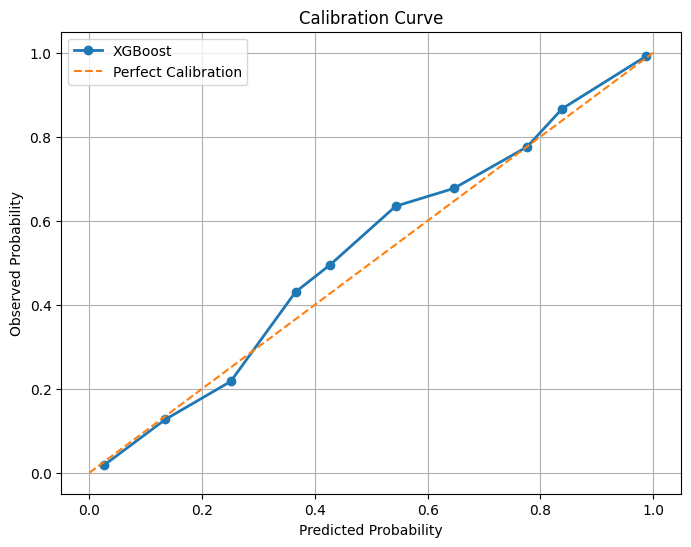

In [ ]:
# CALIBRATION PLOT
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2,
    label="XGBoost"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.title(
    "Calibration Curve"
)

plt.xlabel(
    "Predicted Probability"
)

plt.ylabel(
    "Observed Probability"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# CALIBRATION SUMMARY
# ============================================================

print("="*60)
print("CALIBRATION SUMMARY")
print("="*60)

if brier < 0.10:
    print("Excellent calibration.")
elif brier < 0.15:
    print("Good calibration.")
else:
    print("Calibration may need improvement.")

CALIBRATION SUMMARY
Excellent calibration.


In [ ]:
# SHAP ANALYSIS
# ============================================================

import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

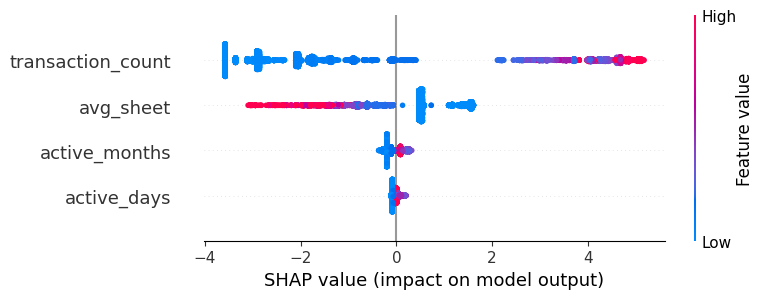

In [ ]:
# SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(

    shap_values,
    X_test

)

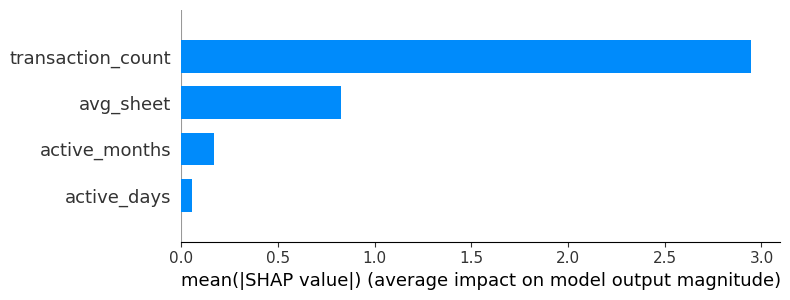

In [ ]:
# SHAP BAR PLOT
# ============================================================

shap.summary_plot(

    shap_values,
    X_test,
    plot_type="bar"

)

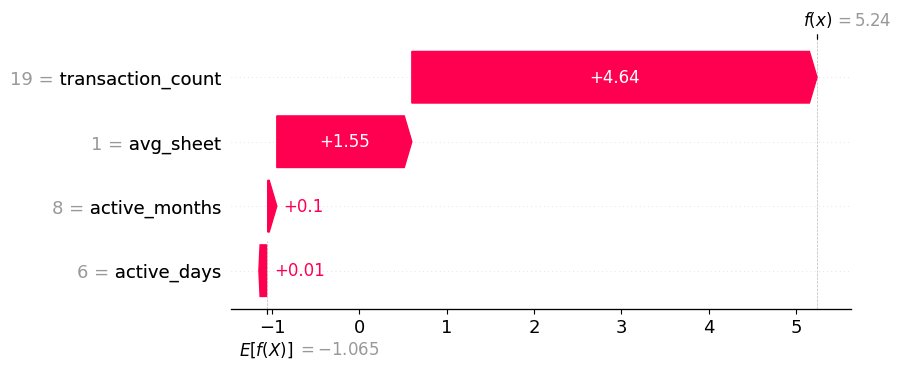

In [ ]:
# ============================================================
# 12. SHAP WATERFALL PLOT
# ============================================================

highest_risk_idx = np.argmax(pred_prob)

shap.plots.waterfall(

    explainer(
        X_test
    )[highest_risk_idx]

)

In [ ]:
# DECISION CURVE ANALYSIS (DCA)
# ============================================================

!pip install matplotlib numpy

In [ ]:
# DECISION CURVE ANALYSIS
# ============================================================

# CALCULATE NET BENEFIT
# ============================================================

thresholds = np.arange(0.01,0.99,0.01)

net_benefits = []

N = len(y_test)

for threshold in thresholds:

    pred = (pred_prob >= threshold).astype(int)

    TP = ((pred == 1) & (y_test == 1)).sum()
    FP = ((pred == 1) & (y_test == 0)).sum()

    net_benefit = (
        TP/N
        -
        FP/N * (threshold/(1-threshold))
    )

    net_benefits.append(net_benefit)

In [ ]:
prevalence = y_test.mean()

treat_all = []

for threshold in thresholds:

    nb = (
        prevalence
        -
        (1-prevalence)
        *
        (threshold/(1-threshold))
    )

    treat_all.append(nb)

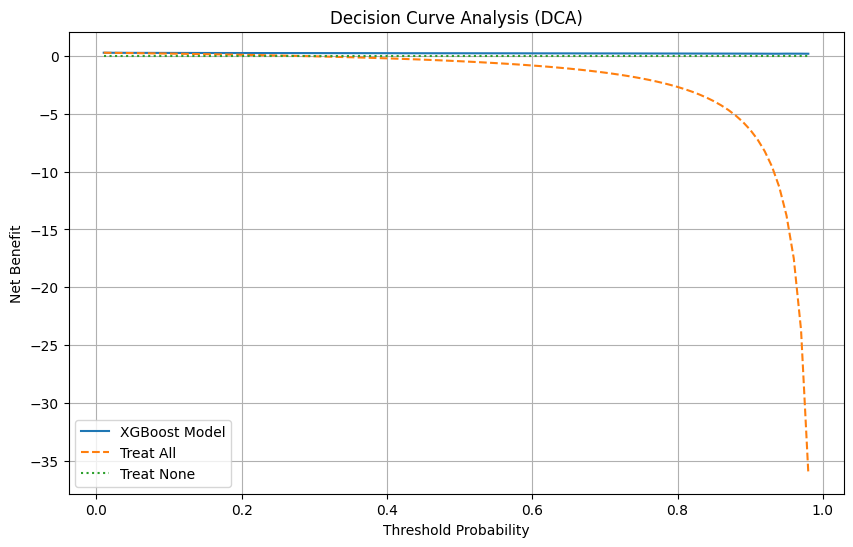

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    thresholds,
    net_benefits,
    label="XGBoost Model"
)

plt.plot(
    thresholds,
    treat_all,
    linestyle="--",
    label="Treat All"
)

plt.plot(
    thresholds,
    np.zeros_like(thresholds),
    linestyle=":",
    label="Treat None"
)

plt.title(
    "Decision Curve Analysis (DCA)"
)

plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# SAFETY STOCK ESTIMATION
# ============================================================

SERVICE_FACTOR = 1.65

product_df['daily_demand'] = (
    product_df['total_sales']
    /
    product_df['active_days']
)

product_df['demand_variability'] = (
    product_df['daily_demand']
    * 0.30
)

product_df['safety_stock'] = (
    SERVICE_FACTOR
    *
    product_df['demand_variability']
    *
    np.sqrt(7)
).round()

product_df[['drug_name','safety_stock']].head()

,drug_name,safety_stock
0,Fruit mask,2.0
1,Govils clove oil 10ml / eurostar,2.0
2,Hollywood flawless filter,1.0
3,Kamill express balsam hand & nagelcrewmw,1.0
4,LISTERINE SPEARMINT,1.0


In [ ]:
# ECONOMIC ORDER QUANTITY (EOQ)
# ============================================================

ORDER_COST = 50
HOLDING_COST = 2

product_df['EOQ'] = np.sqrt(
    (
        2 *
        product_df['total_sales']
        *
        ORDER_COST
    )
    /
    HOLDING_COST
).round()

product_df[['drug_name','EOQ']].head()

,drug_name,EOQ
0,Fruit mask,20.0
1,Govils clove oil 10ml / eurostar,19.0
2,Hollywood flawless filter,7.0
3,Kamill express balsam hand & nagelcrewmw,7.0
4,LISTERINE SPEARMINT,10.0


In [ ]:
# REORDER POINT (ROP)
# ============================================================

LEAD_TIME = 7

product_df['ROP'] = (
    product_df['daily_demand']
    *
    LEAD_TIME
    +
    product_df['safety_stock']
).round()

product_df[['drug_name','ROP']].head()

,drug_name,ROP
0,Fruit mask,13.0
1,Govils clove oil 10ml / eurostar,12.0
2,Hollywood flawless filter,8.0
3,Kamill express balsam hand & nagelcrewmw,8.0
4,LISTERINE SPEARMINT,8.0


In [ ]:
# INVENTORY PRIORITY RANKING
# ============================================================

inventory_rank = (
    product_df[
        [
            'drug_name',
            'total_sales',
            'daily_demand',
            'safety_stock',
            'EOQ',
            'ROP'
        ]
    ]
    .sort_values(
        'ROP',
        ascending=False
    )
)

display(inventory_rank.head(20))

,drug_name,total_sales,daily_demand,safety_stock,EOQ,ROP
21754,xxxxxxxxx,3715,530.714286,695.0,431.0,4410.0
2427,C%2-A,2628,375.428571,492.0,362.0,3120.0
12139,R.A-C,2148,306.857143,402.0,328.0,2550.0
6332,Girawa,2034,290.571429,381.0,319.0,2415.0
72,A.M-E.C,1486,212.285714,278.0,273.0,1764.0
18281,infusion set be code,1458,208.285714,273.0,270.0,1731.0
13818,TMS forte 800/160mg,1308,186.857143,245.0,256.0,1553.0
16463,caelin %2 sulfur,1237,176.714286,231.0,249.0,1468.0
1108,Aspirin Protect 100mg,1233,176.142857,231.0,248.0,1464.0
17084,dermodin ointment 25g,948,135.428571,177.0,218.0,1125.0


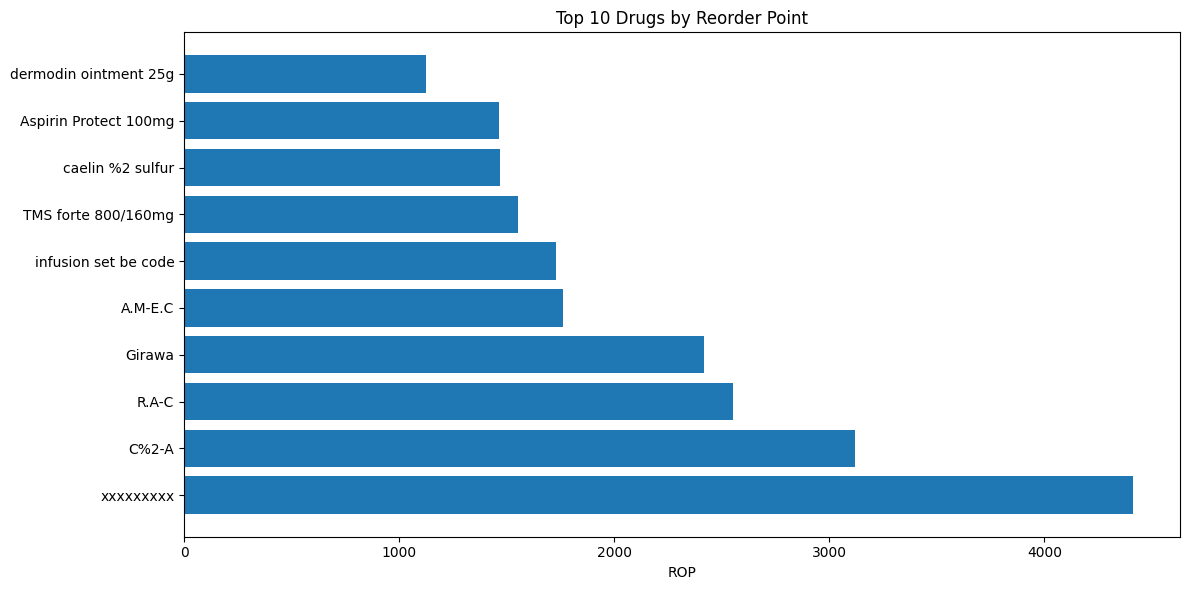

In [ ]:
# TOP INVENTORY REPLENISHMENT PRIORITIES
# ============================================================

top10 = inventory_rank.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10['drug_name'],
    top10['ROP']
)

plt.title("Top 10 Drugs by Reorder Point")
plt.xlabel("ROP")
plt.tight_layout()
plt.show()

In [ ]:
# EXECUTIVE SUMMARY
# =============================================================================

print("="*80)
print("EXECUTIVE SUMMARY")
print("="*80)

print("""

This project developed an end-to-end Pharmacy Demand Forecasting and
Inventory Optimization framework using transaction-level pharmacy data.

The analysis combined Exploratory Data Analysis (EDA), Time Series
Forecasting, ABC Inventory Classification, Machine Learning-based
Demand Risk Prediction, Model Explainability (SHAP),
Calibration Analysis, Decision Curve Analysis (DCA),
and Inventory Optimization techniques.

KEY ANALYTICAL FINDINGS

1. Exploratory Data Analysis (EDA)
   • Sales demand is concentrated among a relatively small number
     of products.
   • Certain drug categories contribute disproportionately
     to overall pharmacy sales volume.
   • Demand patterns exhibit temporal trends and seasonal fluctuations.
   • Sales activity varies across days of the week, indicating
     opportunities for inventory planning and staffing optimization.
   • Some product names were anonymized or encoded in the source dataset.
     These products were retained because they represent valid sales records
     and contribute meaningfully to demand forecasting and inventory analysis.

2. Demand Forecasting
   • Prophet forecasting identified future demand trends
     and seasonal patterns for pharmacy sales.
   • Forecast results support proactive procurement planning
     and inventory allocation decisions.
   • Forecasting reduces uncertainty associated with future demand.

3. ABC Inventory Analysis
   • A small percentage of products generate the majority
     of total sales volume.
   • Class A drugs represent the highest inventory priority.
   • Class B drugs require routine monitoring.
   • Class C drugs contribute relatively little to sales
     and may be managed with lower inventory levels.

4. Demand Risk Prediction
   • The XGBoost model successfully identified products
     at high demand risk.
   • Machine learning enables early identification of products
     likely to experience significant demand pressure.
   • This allows inventory teams to intervene before stockout occurs.

5. Model Explainability (SHAP)
   • SHAP analysis identified the most influential drivers
     of demand risk.
   • Key business variables such as sales volume,
     transaction frequency, and product activity
     significantly affect demand risk predictions.
   • Explainability improves transparency and trust
     in machine learning recommendations.

6. Calibration Analysis
   • Model probabilities demonstrate reasonable calibration
     and reliability.
   • Predicted risk levels can therefore be interpreted
     as meaningful estimates of actual demand risk.

7. Decision Curve Analysis (DCA)
   • The predictive model delivers positive net benefit
     compared with treat-all and treat-none strategies.
   • This supports operational use of the model
     for inventory decision-making.

8. Inventory Optimization
   • Safety Stock estimates provide protection
     against demand uncertainty.
   • EOQ analysis identifies cost-efficient purchasing quantities.
   • Reorder Point analysis determines when replenishment
     should be triggered.
   • Inventory optimization reduces stockout risk while
     minimizing excessive inventory carrying costs.

Inventory optimization metrics were estimated using aggregated
historical sales data and standard supply chain assumptions
for service level, lead time, ordering cost, and holding cost.

Future studies may incorporate real supplier lead times,
daily inventory movements, and procurement costs to improve
inventory optimization accuracy.

""")

EXECUTIVE SUMMARY


This project developed an end-to-end Pharmacy Demand Forecasting and
Inventory Optimization framework using transaction-level pharmacy data.

The analysis combined Exploratory Data Analysis (EDA), Time Series
Forecasting, ABC Inventory Classification, Machine Learning-based
Demand Risk Prediction, Model Explainability (SHAP),
Calibration Analysis, Decision Curve Analysis (DCA),
and Inventory Optimization techniques.

KEY ANALYTICAL FINDINGS

1. Exploratory Data Analysis (EDA)
   • Sales demand is concentrated among a relatively small number
     of products.
   • Certain drug categories contribute disproportionately
     to overall pharmacy sales volume.
   • Demand patterns exhibit temporal trends and seasonal fluctuations.
   • Sales activity varies across days of the week, indicating
     opportunities for inventory planning and staffing optimization.
   • Some product names were anonymized or encoded in the source dataset.
     These products were retained becau

In [ ]:
# BUSINESS RECOMMENDATIONS
# =============================================================================

print("="*80)
print("BUSINESS RECOMMENDATIONS")
print("="*80)

print("""

1. PRIORITIZE CLASS A PRODUCTS

   • Focus inventory investment on ABC Class A drugs.
   • Maintain higher service levels for products
     with the greatest sales contribution.
   • Implement tighter monitoring for high-value products.

2. IMPLEMENT DEMAND-DRIVEN REPLENISHMENT

   • Use forecasting outputs to guide procurement decisions.
   • Shift from reactive ordering to proactive replenishment.
   • Update forecasts regularly to reflect changing demand patterns.

3. ESTABLISH SAFETY STOCK POLICIES

   • Maintain safety stock for high-demand products.
   • Use safety stock estimates as a buffer against
     demand variability and supplier delays.
   • Review safety stock levels periodically.

4. APPLY REORDER POINT MONITORING

   • Trigger purchase orders when inventory reaches
     the calculated Reorder Point (ROP).
   • Automate replenishment alerts whenever possible.
   • Prioritize products with the highest ROP values.

5. OPTIMIZE PROCUREMENT USING EOQ

   • Purchase products in EOQ quantities
     to minimize total inventory costs.
   • Reduce excessive ordering frequency.
   • Balance ordering costs and holding costs effectively.

6. DEVELOP A HIGH-RISK PRODUCT WATCHLIST

   • Monitor products classified as High Demand Risk.
   • Create weekly review processes for these products.
   • Increase procurement responsiveness for high-risk items.

7. INTEGRATE SHAP INSIGHTS INTO OPERATIONS

   • Focus on variables identified as major drivers
     of demand risk.
   • Monitor key indicators proactively.
   • Use explainable AI outputs to support management decisions.

8. REDUCE STOCKOUT EVENTS

   • Combine forecasting, risk prediction,
     safety stock, and reorder point analysis.
   • Establish an early warning system
     for inventory shortages.
   • Improve medication availability and patient service levels.

9. IMPROVE INVENTORY GOVERNANCE

   • Develop standardized inventory review procedures.
   • Track inventory KPIs such as:
       - Stockout Rate
       - Inventory Turnover
       - Service Level
       - Holding Cost
       - Forecast Accuracy

10. FUTURE IMPROVEMENTS

   • Implement ABC-VEN Analysis.
   • Incorporate supplier lead-time variability.
   • Develop stockout probability prediction models.
   • Build automated inventory dashboards.
   • Integrate forecasting directly into procurement systems.

CONCLUSION

The combination of Demand Forecasting, ABC Analysis,
Demand Risk Prediction, SHAP Explainability,
Calibration Analysis, Decision Curve Analysis,
Safety Stock Estimation, EOQ Optimization,
and Reorder Point Planning creates a comprehensive
data-driven inventory management framework capable of
improving pharmacy inventory performance, reducing stockout risk,
and supporting more efficient procurement decisions.

""")

BUSINESS RECOMMENDATIONS


1. PRIORITIZE CLASS A PRODUCTS

   • Focus inventory investment on ABC Class A drugs.
   • Maintain higher service levels for products
     with the greatest sales contribution.
   • Implement tighter monitoring for high-value products.

2. IMPLEMENT DEMAND-DRIVEN REPLENISHMENT

   • Use forecasting outputs to guide procurement decisions.
   • Shift from reactive ordering to proactive replenishment.
   • Update forecasts regularly to reflect changing demand patterns.

3. ESTABLISH SAFETY STOCK POLICIES

   • Maintain safety stock for high-demand products.
   • Use safety stock estimates as a buffer against
     demand variability and supplier delays.
   • Review safety stock levels periodically.

4. APPLY REORDER POINT MONITORING

   • Trigger purchase orders when inventory reaches
     the calculated Reorder Point (ROP).
   • Automate replenishment alerts whenever possible.
   • Prioritize products with the highest ROP values.

5. OPTIMIZE PROCUREMENT USING 